<a href="https://colab.research.google.com/github/bmustafa225/DA-Website/blob/main/fMRI_AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install nilearn

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import nibabel as nb
import nilearn as nl
import matplotlib.pyplot as plt
from nilearn import masking
from nilearn.masking import unmask,apply_mask
from nilearn.plotting import plot_roi, plot_anat

In [ ]:
from nilearn import masking
from nilearn.masking import unmask,apply_mask
from nilearn.plotting import plot_roi, plot_anat



#brain=nb.load('sub-16_T1w.nii.gz')
#brain_vol=brain.get_fdata()
#masker=masking.compute_brain_mask(brain)


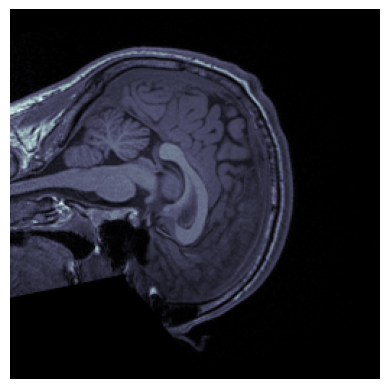

In [ ]:
plt.imshow(brain_vol[88],cmap='bone')
plt.axis('off')
plt.show()

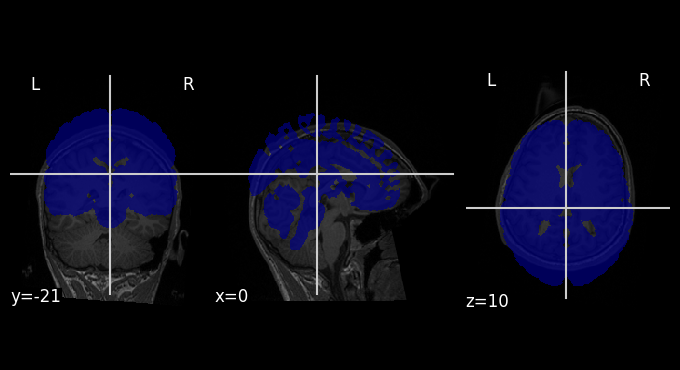

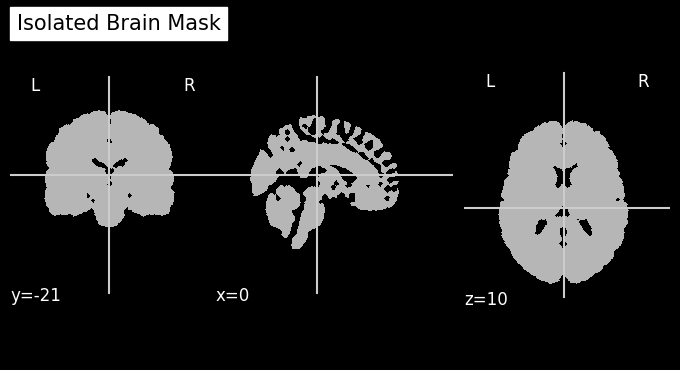

In [ ]:
plot_roi(masker,bg_img=brain)
plot_anat(masker, title="Isolated Brain Mask")

In [ ]:
q=masker.get_fdata()
q.shape

(176, 256, 256)

In [ ]:

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
encode=BrainEncoder(1,16,64).to(device)

mask_weight=masker.get_fdata()
brain_mask=brain_vol*mask_weight

torch_brain=torch.from_numpy(brain_mask.astype(np.float32))
torch_brain=torch_brain.unsqueeze(0).unsqueeze(0)
z=encode(torch_brain)

torch.Size([1, 1, 176, 256, 256])

In [ ]:
z.shape

torch.Size([1, 64])

In [ ]:
decoder=BrainDecoder(1,16,64).to(device)
z_hat=decoder(z)

tensor_mask=torch.from_numpy(mask_weight).unsqueeze(0).unsqueeze(0).to(device)
z_hat_masked = z_hat * tensor_mask
input_masked = torch_brain * tensor_mask
loss = F.mse_loss(z_hat_masked, input_masked, reduction="mean")
loss

tensor(8113.4174, dtype=torch.float64, grad_fn=<MseLossBackward0>)

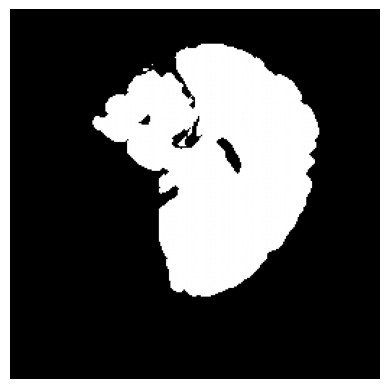

In [ ]:
from nilearn.masking import unmask

reconstructed_fmri= nb.Nifti1Image(z_hat_masked.squeeze().detach().cpu().numpy(), affine=masker.affine, header=masker.header)
recon_img=reconstructed_fmri.get_fdata()

plt.imshow(recon_img[100,:,:],cmap='bone')
plt.axis('off')
plt.show()

Now that we see out autoencoder performing reasonably well on a single fMRI image, lets try scaling the operation using LightningModule for the PyLightning library!

In [ ]:
! pip install lightning

In [ ]:
class BrainEncoder(nn.Module):
  def __init__(self, input: int, base: int,latent:int, act_fn: object=nn.GELU ):
    super().__init__()
    n_hid=base
    self.net=nn.Sequential(
        nn.Conv3d(input,n_hid,kernel_size=3,padding=1,stride=2), #256x256 --> 128x128
        act_fn(),
        nn.Conv3d(n_hid,n_hid,kernel_size=3,padding=1),
        act_fn(),
        nn.Conv3d(n_hid,2*n_hid,kernel_size=3,padding=1,stride=2), #128x128 --> 64x64
        act_fn(),
        nn.Conv3d(2*n_hid,2*n_hid,kernel_size=3,padding=1),
        act_fn(),
        nn.Conv3d(2*n_hid,4*n_hid,kernel_size=3,padding=1,stride=2), #64x64 --> 32x32
        act_fn(),
        nn.Conv3d(4*n_hid,4*n_hid,kernel_size=3,padding=1),
        act_fn(),
        nn.Conv3d(4*n_hid,4*n_hid,kernel_size=3,padding=1,stride=2),#32x32 --> 16x16
        act_fn(),
        nn.AdaptiveAvgPool3d((4,4,4)),
        nn.Flatten(),
        nn.Linear(4 * base * 4 * 4 * 4, latent)
      )
  def forward(self,x):
    return self.net(x)


In [ ]:
class BrainDecoder(nn.Module):
  def __init__(self, input: int, base: int,latent:int, act_fn: object=nn.GELU ):
    self.base=base
    super().__init__()
    self.Linear=nn.Sequential(nn.Linear(latent,4*4*4*4*base),act_fn())
    n_hid=base
    self.net=nn.Sequential(
        nn.ConvTranspose3d(4*n_hid,4*n_hid,padding=1,stride=2,kernel_size=4), #256x256 --> 128x128
        act_fn(),
        nn.ConvTranspose3d(4*n_hid,4*n_hid,kernel_size=4,padding=1),
        act_fn(),
        nn.ConvTranspose3d(4*n_hid,2*n_hid,kernel_size=4,padding=1,stride=2), #128x128 --> 64x64
        act_fn(),
        nn.ConvTranspose3d(2*n_hid,2*n_hid,kernel_size=4,padding=1),
        act_fn(),
        nn.ConvTranspose3d(2*n_hid,2*n_hid,kernel_size=4,padding=1,stride=2),
        act_fn(),
        nn.ConvTranspose3d(2*n_hid,2*n_hid,kernel_size=4,padding=1),
        act_fn(),
        nn.ConvTranspose3d(2*n_hid,n_hid,kernel_size=4,padding=1,stride=2), #64x64 --> 32x32
        act_fn(),
        nn.ConvTranspose3d(n_hid,n_hid,kernel_size=4,padding=1),
        act_fn(),
        nn.ConvTranspose3d(n_hid,input,kernel_size=4,padding=1,stride=2) #32x32 --> 16x16
        #nn.Sigmoid()
      )
  def forward(self,x):
    x=self.Linear(x)
    x=x.unflatten(1,(4*self.base,4,4,4))
    x=self.net(x)
    x=F.interpolate(x, size=(176, 256, 256), mode='trilinear')
    return x


In [ ]:
import torch.optim as optim
import lightning as L

class BrainAutoEncoder(L.LightningModule):
  def __init__(self,
               encoder: object= BrainEncoder,
               decoder: object= BrainDecoder,
               input: int=1 ,base: int=64, latent: int=128,
               brain_mask=None):
    super().__init__()
    self.encoder=encoder(input,base,latent)
    self.decoder=decoder(input,base,latent)


  def forward(self,x):
    z=self.encoder(x)
    x_hat=self.decoder(z)
    return x_hat

  def get_validation_loss(self,batch):
    x=batch[0]
    x_hat=self.forward(x)
    loss=F.mse_loss(x_hat,x , reduction="mean")
    return loss

  def configure_optimizers(self):
    optimizer=optim.Adam(self.parameters(),lr=1e-3)
    return optimizer


  def training_step(self,batch,batch_idx):
    loss_tr=self.get_validation_loss(batch)
    self.log('train_loss',loss_tr)
    return loss_tr

  def validation_step(self,batch,batch_idx):
    loss_vl=self.get_validation_loss(batch)
    self.log('validation_loss',loss_vl)

  def test_step(self,batch):
    loss_tst=self.get_validation_loss(batch)
    self.log('test_loss',loss_tst)



In [ ]:
!pip install torchio

In [ ]:
from typing_extensions import dataclass_transform
import torchio as tio
import zipfile
from torch.utils.data import Dataset
from io import BytesIO
import tempfile

class T1WDataset_mask(Dataset):
  def __init__(self,zip_path,mask_image=True,transform=True):
    self.mask=mask_image
    self.zip_path=zip_path
    with zipfile.ZipFile(zip_path,'r') as z:
      self.image_listdir=[f for f in z.namelist() if f.endswith('.nii') or f.endswith('.nii.gz')]
    self.transform=transform
    # Define TorchIO transform
    self.augment=tio.Compose([tio.CropOrPad((176,256,256)),
                              tio.RandomAffine(scales=(0.95, 1.05), degrees=5)
    ])

  def __len__(self):
    return len(self.image_listdir)

  def __getitem__(self,idx):
    with zipfile.ZipFile(self.zip_path, 'r') as z:
      file_name = self.image_listdir[idx]
      with tempfile.NamedTemporaryFile(suffix='.nii.gz') as tmp:
        tmp.write(z.read(file_name))
        tmp.flush()
        img = nb.load(tmp.name)
        data = img.get_fdata().astype(np.float32)
        affine = img.affine

    scaled_data=( data - data.min())/( data.max() - data.min() + 1e-8)

    if self.mask:
      mask_img=masking.compute_brain_mask(nb.nifti1.Nifti1Image(scaled_data,affine))
      mask=mask_img.get_fdata().astype(np.float32)
    else:
      mask = np.ones_like(scaled_data, dtype=np.float32)

    t1_tensor=torch.from_numpy(scaled_data).unsqueeze(0)
    mask_tensor=torch.from_numpy(mask).unsqueeze(0)

    if self.transform:

      sub=tio.Subject(
          t1w=tio.ScalarImage(tensor=t1_tensor),
          msk=tio.LabelMap(tensor=mask_tensor)
          )
      sub=self.augment(sub)
    else:
      sub=tio.Subject(
          t1w=tio.ScalarImage(tensor=t1_tensor),
          msk=tio.LabelMap(tensor=mask_tensor)
          )

    data_t=sub.t1w.data.float()
    mask_t=sub.msk.data.float()
    data_masked=data_t*mask_t


    return (data_masked,
            mask_t,
            torch.tensor(data.max(),dtype=torch.float32),
            torch.tensor(data.min(),dtype=torch.float32)
    )



In [ ]:

from torch.utils.data import DataLoader
from torch.utils.data import random_split

class T1WDataModule_mask(L.LightningDataModule):
  def __init__(self,zip_path,num_workers=0,mask_image=True,transform=True, batch_size=3):
    super().__init__()
    self.zip_path=zip_path
    self.mask_image=mask_image
    self.transform=transform
    self.num_workers=num_workers
    self.batch_size=batch_size

  def setup(self,stage=None):
    full_data=T1WDataset_mask(self.zip_path,mask_image=self.mask_image,transform=self.transform)
    val_size=int(0.15*len(full_data))
    test_size=int(0.15*len(full_data))
    train_size=len(full_data)-val_size-test_size
    self.train_dataset,self.test_dataset,self.val_dataset=random_split(full_data,[train_size,test_size,val_size])

  def train_dataloader(self):
    return DataLoader(self.train_dataset,batch_size=self.batch_size,num_workers=self.num_workers,shuffle=True)

  def val_dataloader(self):
    return DataLoader(self.val_dataset,batch_size=self.batch_size,num_workers=self.num_workers)

  def test_dataloader(self):
    return DataLoader(self.train_dataset, batch_size=self.batch_size, num_workers=self.num_workers)

In [ ]:
zip_path='/content/anat_T1w_all.zip'
autoencoder_data=T1WDataModule_mask(zip_path,batch_size=2,transform=True,num_workers=0)

In [ ]:
from lightning.pytorch.callbacks import EarlyStopping,ModelCheckpoint

early_stop = EarlyStopping(
    monitor="validation_loss",
    min_delta=1e-4,
    patience=15,
    mode="min"
    )
checkpoint_callback = ModelCheckpoint(
    monitor="validation_loss",           # Same metric as early stopping
    save_top_k=1,                  # Save only the best model
    mode="min",                    # Minimize validation loss
    filename="{epoch}-{val_loss:.4f}", # Useful naming convention
    save_weights_only=False        # Save entire model (not just weights)
    )

model=BrainAutoEncoder(base=16,latent=256)
trainer=L.Trainer(
    max_epochs=300,
    log_every_n_steps=5,
    callbacks=[early_stop,checkpoint_callback],
    accelerator='gpu'
    )
trainer.fit(model,datamodule=autoencoder_data)
trainer.test(model,datamodule=autoencoder_data)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name    | Type         | Params | Mode 
-------------------------------------------------
0 | encoder | BrainEncoder | 1.4 M  | train
1 | decoder | BrainDecoder | 2.0 M  | train
-------------------------------------------------
3.3 M     Trainable params
0         Non-trainable params
3.3 M     Total params
13.318    Total estimated model params size (MB)
41        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.0024614818394184113   │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.0024614818394184113}]

In [ ]:
model.eval()
autoencoder_data.setup()
batch = next(iter(autoencoder_data.val_dataloader()))
x,mask,max,min= batch
x_hat = model(x)
x_hat_rescaled = (x_hat * (max - min + 1e-8) + min)
#mask=masking.compute_brain_mask(x.get_fdata())
x_hat_mask=x_hat_rescaled*mask
# Show a single axial slice
i = 0  # batch index
slice_idx = x.shape[2] // 2  # center slice
plt.subplot(1, 3, 1)
plt.imshow(x[i, 0, slice_idx].cpu(), cmap='gray')
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(x_hat_rescaled[i, 0, slice_idx].detach().cpu(), cmap='gray')
plt.title("Reconstruction No Mask")
plt.show()

plt.subplot(1, 3, 3)
plt.imshow(x_hat_mask[i, 0, slice_idx].detach().cpu(), cmap='gray')
plt.title("Reconstruction With Mask")
plt.show()


RuntimeError: The size of tensor a (256) must match the size of tensor b (2) at non-singleton dimension 4

In [ ]:
print("x:", x.shape, "x_hat:", x_hat.shape, "mask:", mask.shape, "x_max:", max.shape, "x_min:", min.shape)

x: torch.Size([2, 1, 176, 256, 256]) x_hat: torch.Size([2, 1, 176, 256, 256]) mask: torch.Size([2, 1, 176, 256, 256]) x_max: torch.Size([2]) x_min: torch.Size([2])


In [ ]:
class T1WDataset_nomask(Dataset):
  def __init__(self,zip_path,transform=True):
    self.zip_path=zip_path
    with zipfile.ZipFile(zip_path,'r') as z:
      self.image_listdir=[f for f in z.namelist() if f.endswith('.nii') or f.endswith('.nii.gz')]
    self.transform=transform
    # Define TorchIO transform
    self.augment=tio.RandomAffine(scales=(0.95, 1.05), degrees=5)

  def __len__(self):
    return len(self.image_listdir)

  def __getitem__(self,idx):
    with zipfile.ZipFile(self.zip_path, 'r') as z:
      file_name = self.image_listdir[idx]
      with tempfile.NamedTemporaryFile(suffix='.nii.gz') as tmp:
        tmp.write(z.read(file_name))
        tmp.flush()
        img = nb.load(tmp.name)
        data = img.get_fdata().astype(np.float32)
        affine = img.affine

    scaled_data=( data - data.min())/( data.max() - data.min() + 1e-8)

    if self.transform:

      t1_tensor=torch.from_numpy(scaled_data).unsqueeze(0)
      sub=tio.Subject(t1w=tio.ScalarImage(tensor=t1_tensor))
      sub1=self.augment(sub)
      data=sub1.t1w.data.squeeze().numpy()


    return (torch.from_numpy(data).unsqueeze(0),
            torch.tensor(data.max(),dtype=torch.float32),
            torch.tensor(data.min(),dtype=torch.float32)
    )

class T1WDataModule_nomask(L.LightningDataModule):
  def __init__(self,zip_path,num_workers=0,transform=True, batch_size=3):
    super().__init__()
    self.zip_path=zip_path
    self.transform=transform
    self.num_workers=num_workers
    self.batch_size=batch_size

  def setup(self,stage=None):
    full_data=T1WDataset_nomask(self.zip_path,transform=self.transform)
    val_size=int(0.15*len(full_data))
    test_size=int(0.15*len(full_data))
    train_size=len(full_data)-val_size-test_size
    self.train_dataset,self.test_dataset,self.val_dataset=random_split(full_data,[train_size,test_size,val_size])

  def train_dataloader(self):
    return DataLoader(self.train_dataset,batch_size=self.batch_size,num_workers=self.num_workers,shuffle=True)

  def val_dataloader(self):
    return DataLoader(self.val_dataset,batch_size=self.batch_size,num_workers=self.num_workers)

  def test_dataloader(self):
    return DataLoader(self.train_dataset, batch_size=self.batch_size, num_workers=self.num_workers)

In [ ]:
zip_path='/content/anat_T1w_extract.zip'
autoencoder_nomaskdata=T1WDataModule_nomask(zip_path,batch_size=2,transform=True,num_workers=0)

In [ ]:
from lightning.pytorch.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="validation_loss",min_delta=0.0001, patience=8, mode="min")
model_nomask=BrainAutoEncoder(base=16,latent=256)
trainer_nomask=L.Trainer(max_epochs=50,log_every_n_steps=5,callbacks=[early_stop],accelerator='gpu')
trainer_nomask.fit(model_nomask,datamodule=autoencoder_nomaskdata)
trainer_nomask.test(model_nomask,datamodule=autoencoder_nomaskdata)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name    | Type      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.005244841333478689    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.005244841333478689}]

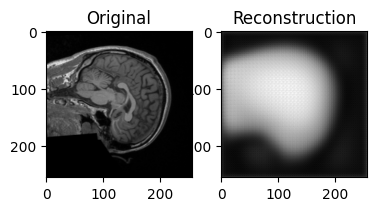

In [ ]:
model_nomask.eval()
autoencoder_nomaskdata.setup()
batch = next(iter(autoencoder_nomaskdata.val_dataloader()))
x,max,min= batch
x_hat = model_nomask(x)
#x_hat_rescaled = ((x_hat * (max - min + 1e-8)) + min)
#mask_img=masking.compute_brain_mask(nb.nifti1.Nifti1Image(x,affine=affine))
#x_hat_mask=x_hat_rescaled*mask
# Show a single axial slice
i = 0  # batch index
slice_idx = x.shape[2] // 2  # center slice
plt.subplot(1, 2, 1)
plt.imshow(x[i, 0, slice_idx].cpu(), cmap='gray')
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(x_hat[i, 0, slice_idx].detach().cpu(), cmap='gray')
plt.title("Reconstruction")
plt.show()



In [ ]:

def autoencoder_latent_test(latent_dim):
  model=BrainAutoEncoder(latent=latent_dim)
  trainer=L.Trainer(max_epochs=20,log_every_n_steps=5,accelerator='gpu')
  trainer.fit(model,datamodule=autoencoder_data)

  val_score=trainer.validate(model,datamodule=autoencoder_data)
  test_score=trainer.test(model,datamodule=autoencoder_data)
  result = {"test": test_score, "val": val_score}
  return model,result

In [ ]:
latent_tests=[64,128,256,384]
model_dict={}
for l in latent_tests:
  model_ld,result_ld=autoencoder_latent_test(l)
  model_dict[l]={"model": model_ld, "result": result_ld}

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('m

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      validation_loss      │      9097.7783203125      │
└───────────────────────────┴───────────────────────────┘

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │        10393.21875        │
└───────────────────────────┴───────────────────────────┘

In [ ]:
model_dict

{64: {'model': BrainAutoEncoder(
    (encoder): BrainEncoder(
      (net): Sequential(
        (0): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
        (1): GELU(approximate='none')
        (2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (3): GELU(approximate='none')
        (4): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
        (5): GELU(approximate='none')
        (6): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (7): GELU(approximate='none')
        (8): Conv3d(128, 256, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
        (9): GELU(approximate='none')
        (10): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (11): GELU(approximate='none')
        (12): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
        (13): GELU(approximate='none')
        (14): Adapt

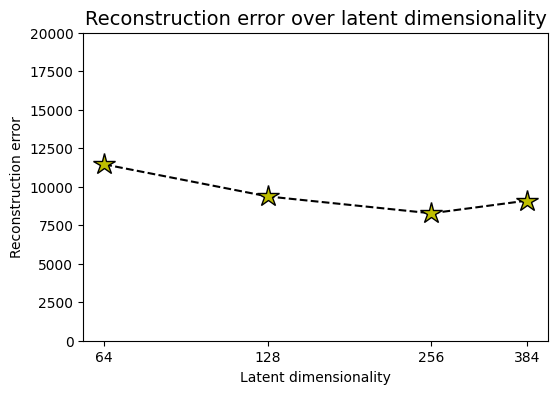

In [ ]:
latent_dims = sorted([k for k in model_dict])
val_scores = [model_dict[k]["result"]["val"][0]['validation_loss'] for k in latent_dims]

fig = plt.figure(figsize=(6,4))
plt.plot(latent_tests, val_scores, '--', color="#000", marker="*", markeredgecolor="#000", markerfacecolor="y", markersize=16)
plt.xscale("log")
plt.xticks(latent_dims, labels=latent_dims)
plt.title("Reconstruction error over latent dimensionality", fontsize=14)
plt.xlabel("Latent dimensionality")
plt.ylabel("Reconstruction error")
plt.minorticks_off()
plt.ylim(0,20000)
plt.show()

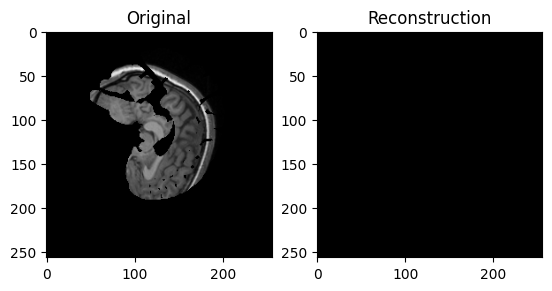

In [ ]:
model=model_dict[256]['model']
model.eval()
batch = next(iter(autoencoder_data.val_dataloader()))
x, _ = batch
x_hat = model(x)

# Show a single axial slice
i = 0  # batch index
slice_idx = x.shape[2] // 2  # center slice
plt.subplot(1, 2, 1)
plt.imshow(x[i,0, slice_idx].cpu(), cmap='gray')
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(x_hat[i, 0, slice_idx].detach().cpu(), cmap='gray')
plt.title("Reconstruction")
plt.show()

BrainAutoEncoder(
  (encoder): BrainEncoder(
    (net): Sequential(
      (0): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
      (1): GELU(approximate='none')
      (2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (3): GELU(approximate='none')
      (4): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
      (5): GELU(approximate='none')
      (6): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (7): GELU(approximate='none')
      (8): Conv3d(128, 256, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
      (9): GELU(approximate='none')
      (10): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (11): GELU(approximate='none')
      (12): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
      (13): GELU(approximate='none')
      (14): AdaptiveAvgPool3d(output_size=(4, 4, 4))
      (15): F

In conclusion, the model was capable of reducing dimensionality but failde at being able to reconstruct the images. The large MSE values suggest further refinement and fine-tuning the model to improve the compression of a 176x256x256 fMRI T1W image of the brain. This project was an attempt to